# Nantucket Electricity Demand and Price Data

This notebooks analyzes electricity price and demand data from `ISONE_data` and is used to create Figure 2 of the manuscript and the data file `Nantucket_2024.csv`, which is read by `code/01_data.jl` when populating the data structure for the investment planning problem.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

In [ ]:
# Read 2024 price and demand data
month_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
df = []
for mh in month_list:
    df_new = pd.read_csv("ISONE_data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
df.to_csv('Nantucket_2024.csv', index = False)

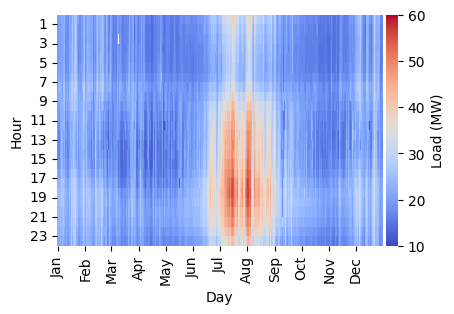

In [4]:
# Demand heatmap
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_load, annot=False, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('../pics/load_24.svg', format='svg', bbox_inches = 'tight')
plt.savefig('../pics/load_24.pdf', format='pdf', bbox_inches = 'tight')

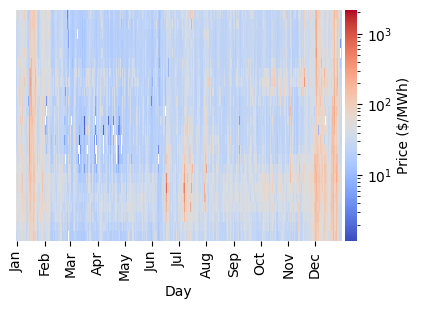

In [5]:
# Price heatmap
hm_price = df.pivot(index = "Hour", columns = "Day", values = "Price")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, norm = LogNorm(), yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmin = 0.001)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('../pics/price_24.svg', format='svg', bbox_inches = 'tight')
plt.savefig('../pics/price_24.pdf', format='pdf', bbox_inches = 'tight')